# Middle model: uses test inputs, but nothing is tuned on the leaderboard

| | v8 | Clean | **Middle** |
|---|---|---|---|
| Leaderboard RMSE | 3.27026 | 3.401387 | not submitted yet |
| Learns from test **inputs** (never answers) | yes | no | **yes** |
| Blend weight chosen by | leaderboard scores | cross-validation | **cross-validation on train** |
| Random seeds averaged | 1 | 1 | **3** |

The clean model showed that using test inputs is worth about 0.13. That's a semi-supervised technique, not overfitting, because no test answers are involved. The overfitting risk came from picking blend weights with leaderboard scores. This model keeps the test-aware ingredients but picks its weight by cross-validation on `train.csv`. Code: `middle_model.py`.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import middle_model as MM, final_model as F
train, test = F.load_data()
d = np.load(MM.CV_FILE)            # 5-fold cross-validation predictions saved by middle_model.py
idx, A, B = d['idx'], d['A'], d['B']
weight, table = MM.choose_weight(train, test, idx, A, B)
print(f'{len(idx):,} complete training rows, each predicted by models that never saw it, '
      f'with {A.shape[0]} draws of blank patterns copied from test rows')

7,537 complete training rows, each predicted by models that never saw it, with 3 draws of blank patterns copied from test rows


## How the weight was chosen

Each training row is predicted by models trained on the other four-fifths of the data. Blank patterns copied from real test rows are applied to the validation rows, so the check rehearses test conditions. Two scores are computed for every weight:

- **test-like blanks:** plain RMSE;
- **test-mix weighted:** the same errors, weighted so the building and event mix matches the test set (computed from test inputs only).

The chosen weight minimizes the average of the two.

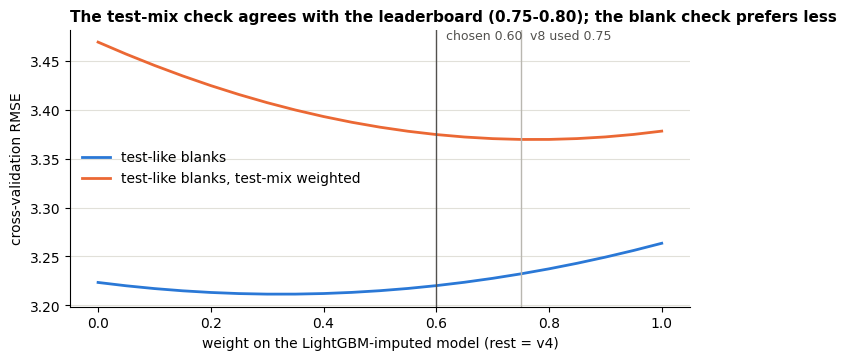

,test-like blanks,"test-like blanks, test-mix weighted",average
weight on B,,,
0.00,3.2234,3.4692,3.3463
0.35,3.2115,3.3998,3.3056
0.50,3.2150,3.3822,3.2986
0.60,3.2201,3.3747,3.2974
0.75,3.2322,3.3697,3.3009
0.80,3.2373,3.3697,3.3035
1.00,3.2635,3.3782,3.3208


In [2]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(table['weight on B'], table['test-like blanks'], color='#2a78d6', linewidth=2, label='test-like blanks')
ax.plot(table['weight on B'], table['test-like blanks, test-mix weighted'], color='#eb6834', linewidth=2, label='test-like blanks, test-mix weighted')
for x, txt in [(weight, f'chosen {weight:.2f}'), (0.75, 'v8 used 0.75')]:
    ax.axvline(x, color='#52514e' if x == weight else '#b9b7b0', linewidth=1)
    ax.text(x + 0.01, ax.get_ylim()[1], ' ' + txt, va='top', fontsize=9, color='#52514e')
ax.set_xlabel('weight on the LightGBM-imputed model (rest = v4)')
ax.set_ylabel('cross-validation RMSE')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', color='#e1e0d9')
ax.legend(frameon=False, loc='center left')
ax.set_title('The test-mix check agrees with the leaderboard (0.75-0.80); the blank check prefers less', loc='left', fontsize=11, fontweight='bold')
plt.show()
display(table.set_index('weight on B').loc[[0.0, 0.35, 0.5, 0.6, 0.75, 0.8, 1.0]].round(4))

**Reading this:**

- The **test-mix weighted** check, built only from test inputs, independently prefers about 0.75–0.80 on the LightGBM model. That's the same weight your leaderboard scores pointed to, so v8's weight wasn't just luck.
- The **test-like blanks** check prefers about 0.35.
- The chosen **0.60** balances the two without using any leaderboard score.

In [3]:
v4 = F.v4_predictions(train, test, source='file')
new = F.new_model_predictions(train, test, seeds=MM.SEEDS)
pred = F.blend(v4, new, weight)
saved = pd.read_csv(F.ROOT / 'candidate_middle.csv')
print(f'candidate_middle.csv reproduced to within {np.abs(saved.prediction.to_numpy() - pred).max():.6f}')
for f, s in [('candidate_v8.csv', '3.27026'), ('candidate_v5_lightgbm.csv', '3.29'), ('candidate_clean.csv', '3.401387')]:
    other = pd.read_csv(F.ROOT / f).prediction.to_numpy()
    print(f'RMS difference from {f} ({s}): {np.sqrt(np.mean((pred - other) ** 2)):.3f}')

candidate_middle.csv reproduced to within 0.000000
RMS difference from candidate_v8.csv (3.27026): 0.205
RMS difference from candidate_v5_lightgbm.csv (3.29): 0.133
RMS difference from candidate_clean.csv (3.401387): 0.590


## What to expect

The middle model sits between v5 (weight 0.50, 3.29) and v7/v8 (0.65–0.75, about 3.27), so expect about **3.28**. Even if it scores slightly worse than v8, it's the choice with the least leaderboard tuning while still using the test inputs that clearly help.